In [620]:
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
import matplotlib.pyplot as plt

In [621]:
retirar = (1,0)
retirar2 = (2,2)
valor_l_c = 7

celulas = {}

base_peso = {}
base = {}
for i in range(valor_l_c):
    for j in range(valor_l_c):
        # print((i,j),(retirar[0],retirar[1]))
        if (i,j)!=(retirar[0],retirar[1]) and (i,j)!=(retirar2[0],retirar2[1]):
            peso = np.random.choice([0,1])
            celulas[i,j] = np.random.randint(low=300,high=600)
            
            base_peso[i,j] = peso

            base[i,j] = np.random.choice([0,1])



origem = 0
destino = valor_l_c-1

base

{(0, 0): np.int64(1),
 (0, 1): np.int64(1),
 (0, 2): np.int64(1),
 (0, 3): np.int64(0),
 (0, 4): np.int64(0),
 (0, 5): np.int64(1),
 (0, 6): np.int64(0),
 (1, 1): np.int64(1),
 (1, 2): np.int64(0),
 (1, 3): np.int64(0),
 (1, 4): np.int64(0),
 (1, 5): np.int64(0),
 (1, 6): np.int64(1),
 (2, 0): np.int64(0),
 (2, 1): np.int64(0),
 (2, 3): np.int64(0),
 (2, 4): np.int64(0),
 (2, 5): np.int64(1),
 (2, 6): np.int64(0),
 (3, 0): np.int64(1),
 (3, 1): np.int64(1),
 (3, 2): np.int64(0),
 (3, 3): np.int64(1),
 (3, 4): np.int64(0),
 (3, 5): np.int64(1),
 (3, 6): np.int64(1),
 (4, 0): np.int64(0),
 (4, 1): np.int64(1),
 (4, 2): np.int64(0),
 (4, 3): np.int64(0),
 (4, 4): np.int64(0),
 (4, 5): np.int64(1),
 (4, 6): np.int64(0),
 (5, 0): np.int64(0),
 (5, 1): np.int64(1),
 (5, 2): np.int64(0),
 (5, 3): np.int64(0),
 (5, 4): np.int64(0),
 (5, 5): np.int64(1),
 (5, 6): np.int64(1),
 (6, 0): np.int64(0),
 (6, 1): np.int64(0),
 (6, 2): np.int64(0),
 (6, 3): np.int64(0),
 (6, 4): np.int64(1),
 (6, 5): n

In [622]:
celulas

{(0, 0): 470,
 (0, 1): 323,
 (0, 2): 534,
 (0, 3): 321,
 (0, 4): 460,
 (0, 5): 352,
 (0, 6): 565,
 (1, 1): 451,
 (1, 2): 518,
 (1, 3): 319,
 (1, 4): 595,
 (1, 5): 527,
 (1, 6): 412,
 (2, 0): 534,
 (2, 1): 422,
 (2, 3): 482,
 (2, 4): 413,
 (2, 5): 434,
 (2, 6): 532,
 (3, 0): 409,
 (3, 1): 431,
 (3, 2): 572,
 (3, 3): 432,
 (3, 4): 421,
 (3, 5): 379,
 (3, 6): 388,
 (4, 0): 341,
 (4, 1): 555,
 (4, 2): 375,
 (4, 3): 544,
 (4, 4): 486,
 (4, 5): 559,
 (4, 6): 422,
 (5, 0): 424,
 (5, 1): 575,
 (5, 2): 372,
 (5, 3): 443,
 (5, 4): 368,
 (5, 5): 350,
 (5, 6): 542,
 (6, 0): 538,
 (6, 1): 523,
 (6, 2): 427,
 (6, 3): 388,
 (6, 4): 562,
 (6, 5): 336,
 (6, 6): 563}

In [623]:
vizinhos = {}
for i,j in list(base.keys()):
    vizinho_viaveis = []
    # print(f"Vizinhos de ({i}, {j}):")
    cima = (i-1, j)
    baixo = (i+1, j)
    esquerda = (i, j-1)
    direita = (i, j+1)
    vizinho= [cima, baixo, esquerda, direita]
    for v in vizinho:
        
        if v[0] >=0 and v[0] < valor_l_c and v[1] >= 0 and v[1] < valor_l_c  and (v[0], v[1])!=(retirar[0],retirar[1]) and (v[0], v[1])!=(retirar2[0],retirar2[1]):
            vizinho_viaveis.append(v)               
    vizinhos[(i, j)] = vizinho_viaveis


for k in vizinhos:
    print(k, vizinhos[k])

(0, 0) [(0, 1)]
(0, 1) [(1, 1), (0, 0), (0, 2)]
(0, 2) [(1, 2), (0, 1), (0, 3)]
(0, 3) [(1, 3), (0, 2), (0, 4)]
(0, 4) [(1, 4), (0, 3), (0, 5)]
(0, 5) [(1, 5), (0, 4), (0, 6)]
(0, 6) [(1, 6), (0, 5)]
(1, 1) [(0, 1), (2, 1), (1, 2)]
(1, 2) [(0, 2), (1, 1), (1, 3)]
(1, 3) [(0, 3), (2, 3), (1, 2), (1, 4)]
(1, 4) [(0, 4), (2, 4), (1, 3), (1, 5)]
(1, 5) [(0, 5), (2, 5), (1, 4), (1, 6)]
(1, 6) [(0, 6), (2, 6), (1, 5)]
(2, 0) [(3, 0), (2, 1)]
(2, 1) [(1, 1), (3, 1), (2, 0)]
(2, 3) [(1, 3), (3, 3), (2, 4)]
(2, 4) [(1, 4), (3, 4), (2, 3), (2, 5)]
(2, 5) [(1, 5), (3, 5), (2, 4), (2, 6)]
(2, 6) [(1, 6), (3, 6), (2, 5)]
(3, 0) [(2, 0), (4, 0), (3, 1)]
(3, 1) [(2, 1), (4, 1), (3, 0), (3, 2)]
(3, 2) [(4, 2), (3, 1), (3, 3)]
(3, 3) [(2, 3), (4, 3), (3, 2), (3, 4)]
(3, 4) [(2, 4), (4, 4), (3, 3), (3, 5)]
(3, 5) [(2, 5), (4, 5), (3, 4), (3, 6)]
(3, 6) [(2, 6), (4, 6), (3, 5)]
(4, 0) [(3, 0), (5, 0), (4, 1)]
(4, 1) [(3, 1), (5, 1), (4, 0), (4, 2)]
(4, 2) [(3, 2), (5, 2), (4, 1), (4, 3)]
(4, 3) [(3, 3), 

In [624]:
# criar os arcos do grafo
custo_passo = 1
arcos = []
arcos_custo = {}
keys = list(vizinhos.keys())
for i,(j,k) in enumerate(vizinhos.items()):
    # print(i, j, k)
    for jk in k:
        # print(f"Arco: {j} -> {jk}")
        
        soma = base_peso[jk[0], jk[1]] + base_peso[j[0], j[1]] + custo_passo
        arcos_custo[(j, jk)] = soma

arcos_carga = {}

for i,(j,k) in enumerate(vizinhos.items()):
    # print(i, j, k)
    for jk in k:
        # print(f"Arco: {j} -> {jk}")
        
        soma = celulas[jk[0], jk[1]] 
        arcos_carga[(j, jk)] = soma


In [625]:
arcos_custo

{((0, 0), (0, 1)): np.int64(1),
 ((0, 1), (1, 1)): np.int64(1),
 ((0, 1), (0, 0)): np.int64(1),
 ((0, 1), (0, 2)): np.int64(2),
 ((0, 2), (1, 2)): np.int64(2),
 ((0, 2), (0, 1)): np.int64(2),
 ((0, 2), (0, 3)): np.int64(3),
 ((0, 3), (1, 3)): np.int64(2),
 ((0, 3), (0, 2)): np.int64(3),
 ((0, 3), (0, 4)): np.int64(3),
 ((0, 4), (1, 4)): np.int64(2),
 ((0, 4), (0, 3)): np.int64(3),
 ((0, 4), (0, 5)): np.int64(2),
 ((0, 5), (1, 5)): np.int64(2),
 ((0, 5), (0, 4)): np.int64(2),
 ((0, 5), (0, 6)): np.int64(1),
 ((0, 6), (1, 6)): np.int64(2),
 ((0, 6), (0, 5)): np.int64(1),
 ((1, 1), (0, 1)): np.int64(1),
 ((1, 1), (2, 1)): np.int64(1),
 ((1, 1), (1, 2)): np.int64(1),
 ((1, 2), (0, 2)): np.int64(2),
 ((1, 2), (1, 1)): np.int64(1),
 ((1, 2), (1, 3)): np.int64(1),
 ((1, 3), (0, 3)): np.int64(2),
 ((1, 3), (2, 3)): np.int64(2),
 ((1, 3), (1, 2)): np.int64(1),
 ((1, 3), (1, 4)): np.int64(1),
 ((1, 4), (0, 4)): np.int64(2),
 ((1, 4), (2, 4)): np.int64(2),
 ((1, 4), (1, 3)): np.int64(1),
 ((1, 4)

In [626]:
matriz_soma = {}
for k in keys:
    matriz_soma[k] = 0
# origens

matriz_soma[origem,origem]= -300
#destino
matriz_soma[destino,destino]= 200

destino2 = (2,0)
matriz_soma[destino2]=100



In [627]:
matriz_soma

{(0, 0): -300,
 (0, 1): 0,
 (0, 2): 0,
 (0, 3): 0,
 (0, 4): 0,
 (0, 5): 0,
 (0, 6): 0,
 (1, 1): 0,
 (1, 2): 0,
 (1, 3): 0,
 (1, 4): 0,
 (1, 5): 0,
 (1, 6): 0,
 (2, 0): 100,
 (2, 1): 0,
 (2, 3): 0,
 (2, 4): 0,
 (2, 5): 0,
 (2, 6): 0,
 (3, 0): 0,
 (3, 1): 0,
 (3, 2): 0,
 (3, 3): 0,
 (3, 4): 0,
 (3, 5): 0,
 (3, 6): 0,
 (4, 0): 0,
 (4, 1): 0,
 (4, 2): 0,
 (4, 3): 0,
 (4, 4): 0,
 (4, 5): 0,
 (4, 6): 0,
 (5, 0): 0,
 (5, 1): 0,
 (5, 2): 0,
 (5, 3): 0,
 (5, 4): 0,
 (5, 5): 0,
 (5, 6): 0,
 (6, 0): 0,
 (6, 1): 0,
 (6, 2): 0,
 (6, 3): 0,
 (6, 4): 0,
 (6, 5): 0,
 (6, 6): 200}

In [628]:

model = pyo.ConcreteModel()

model.k = pyo.Set(initialize=keys)
model.arcos_key = pyo.Set(initialize=list(arcos_custo.keys()))
model.arcos_custo = pyo.Param(model.arcos_key, initialize=arcos_custo)
model.matriz_s = pyo.Param(model.k, initialize=matriz_soma)
model.x = pyo.Var(model.arcos_key, domain=pyo.NonNegativeIntegers)

model.a_carga = pyo.Param(model.arcos_key,initialize=arcos_carga)

In [629]:
#Função objetivo

def func_obj(model):
    return sum(model.arcos_custo[a] * model.x[a] for a in model.arcos_key)
model.obj = pyo.Objective(rule=func_obj, sense=pyo.minimize)

In [630]:
# Restrição balanço

def func_balanco(model,i,j):
    #tudo que entra para cada i-J menos tudo que sai de cada J tem que ser igual a matriz
    entra = sum(model.x[l,m,i,j] for l,m in vizinhos[i,j])
    sai = sum(model.x[i,j,l,m,] for l,m in vizinhos[i,j])
    return entra-sai == model.matriz_s[i,j]

model.balanco = pyo.Constraint(model.k, rule=func_balanco)

In [631]:
# Restrição carga máximo por arco

def func_carga(model,a,b,c,d):
    return model.x[a,b,c,d] <= model.a_carga[a,b,c,d]
model.rest_carga = pyo.Constraint(model.arcos_key,rule = func_carga)

In [632]:
model.pprint()

2 Set Declarations
    arcos_key : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     4 :    Any :  154 : {(0, 0, 0, 1), (0, 1, 1, 1), (0, 1, 0, 0), (0, 1, 0, 2), (0, 2, 1, 2), (0, 2, 0, 1), (0, 2, 0, 3), (0, 3, 1, 3), (0, 3, 0, 2), (0, 3, 0, 4), (0, 4, 1, 4), (0, 4, 0, 3), (0, 4, 0, 5), (0, 5, 1, 5), (0, 5, 0, 4), (0, 5, 0, 6), (0, 6, 1, 6), (0, 6, 0, 5), (1, 1, 0, 1), (1, 1, 2, 1), (1, 1, 1, 2), (1, 2, 0, 2), (1, 2, 1, 1), (1, 2, 1, 3), (1, 3, 0, 3), (1, 3, 2, 3), (1, 3, 1, 2), (1, 3, 1, 4), (1, 4, 0, 4), (1, 4, 2, 4), (1, 4, 1, 3), (1, 4, 1, 5), (1, 5, 0, 5), (1, 5, 2, 5), (1, 5, 1, 4), (1, 5, 1, 6), (1, 6, 0, 6), (1, 6, 2, 6), (1, 6, 1, 5), (2, 0, 3, 0), (2, 0, 2, 1), (2, 1, 1, 1), (2, 1, 3, 1), (2, 1, 2, 0), (2, 3, 1, 3), (2, 3, 3, 3), (2, 3, 2, 4), (2, 4, 1, 4), (2, 4, 3, 4), (2, 4, 2, 3), (2, 4, 2, 5), (2, 5, 1, 5), (2, 5, 3, 5), (2, 5, 2, 4), (2, 5, 2, 6), (2, 6, 1, 6), (2, 6, 3, 6), (2, 6, 2, 5), (3, 0, 2, 0), (3, 0, 4, 0), 

In [633]:
opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
res = opt.solve(model,tee=True)


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer Community Edition 22.2.0.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2026.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\Pichau\AppData\Local\Temp\tmpqyv4yl8p.cplex.log' open.
CPLEX> Problem 'C:\Users\Pichau\AppData\Local\Temp\tmpixfyzf3g.pyomo.lp' read.
Read time = 0.00 sec. (0.01 ticks)
CPLEX> Problem name         : C:\Users\Pichau\AppData\Local\Temp\tmpixfyzf3g.pyomo.lp
Objective sense      : Minimize
Variables            :     154  [General Integer: 154]
Objective nonzeros   :     154
Linear constraints   :     201  [Less: 154,  Equal: 47]
  Nonzeros           :     462
  RHS nonzeros       :     157

Variables            : Min LB: 0.000000         Max UB: all infinite   
Objective

In [634]:
valores = []
val_valores=  {}
for s in model.x:
    val_valores[s]= pyo.value(model.x[s])
    print(s,":",pyo.value(model.x[s]))
valores = [s for s in model.x if pyo.value(model.x[s])!=0]

(0, 0, 0, 1) : 300.0
(0, 1, 1, 1) : 300.0
(0, 1, 0, 0) : 0.0
(0, 1, 0, 2) : 0.0
(0, 2, 1, 2) : -0.0
(0, 2, 0, 1) : -0.0
(0, 2, 0, 3) : -0.0
(0, 3, 1, 3) : -0.0
(0, 3, 0, 2) : -0.0
(0, 3, 0, 4) : -0.0
(0, 4, 1, 4) : -0.0
(0, 4, 0, 3) : -0.0
(0, 4, 0, 5) : -0.0
(0, 5, 1, 5) : -0.0
(0, 5, 0, 4) : -0.0
(0, 5, 0, 6) : 0.0
(0, 6, 1, 6) : -0.0
(0, 6, 0, 5) : -0.0
(1, 1, 0, 1) : -0.0
(1, 1, 2, 1) : 100.0
(1, 1, 1, 2) : 200.0
(1, 2, 0, 2) : -0.0
(1, 2, 1, 1) : -0.0
(1, 2, 1, 3) : 200.0
(1, 3, 0, 3) : 0.0
(1, 3, 2, 3) : 200.0
(1, 3, 1, 2) : -0.0
(1, 3, 1, 4) : 0.0
(1, 4, 0, 4) : 0.0
(1, 4, 2, 4) : 0.0
(1, 4, 1, 3) : -0.0
(1, 4, 1, 5) : 0.0
(1, 5, 0, 5) : -0.0
(1, 5, 2, 5) : -0.0
(1, 5, 1, 4) : -0.0
(1, 5, 1, 6) : -0.0
(1, 6, 0, 6) : -0.0
(1, 6, 2, 6) : -0.0
(1, 6, 1, 5) : -0.0
(2, 0, 3, 0) : -0.0
(2, 0, 2, 1) : -0.0
(2, 1, 1, 1) : -0.0
(2, 1, 3, 1) : 0.0
(2, 1, 2, 0) : 100.0
(2, 3, 1, 3) : -0.0
(2, 3, 3, 3) : 200.0
(2, 3, 2, 4) : -0.0
(2, 4, 1, 4) : -0.0
(2, 4, 3, 4) : -0.0
(2, 4, 2, 3) : -0.0
(

C:\Users\Pichau\AppData\Local\Temp\ipykernel_9364\884869022.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(y,x,vmin=0,vmax=linha, color='black')


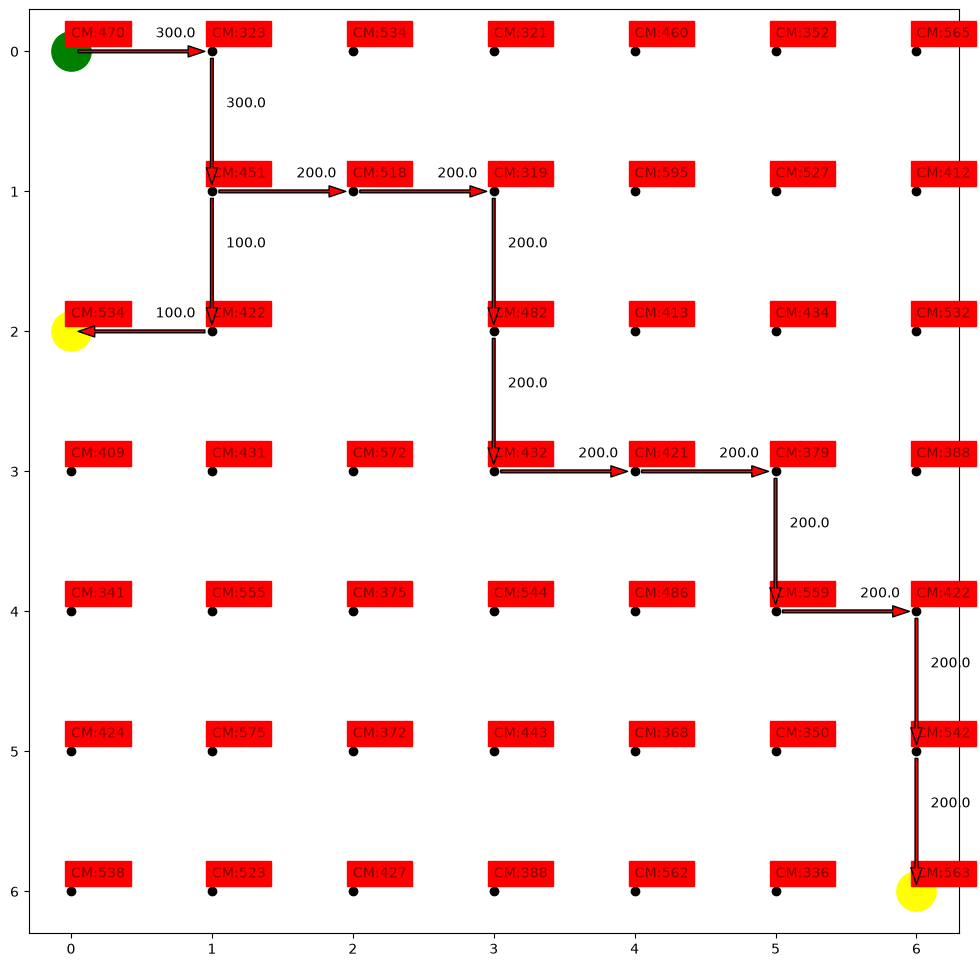

In [635]:
from matplotlib.pyplot import arrow


linha= valor_l_c-1
fig, ax = plt.subplots(figsize=(linha*2,linha*2))


# ax.grid(True)
ax.set_xbound(0,linha-1)            
ax.set_ybound(0,linha-1)  
# ax.invert_xaxis()  
ax.invert_yaxis()  

for x,y in keys:
    ax.scatter(y,x,vmin=0,vmax=linha, color='black')
    ax.text(y,x-0.1,f"CM:{celulas[x,y]}",backgroundcolor='red',alpha=0.5)

for a,b,c,d in valores:
    # print(a,b,c,d)
    ax.annotate(text="", xytext=(b,a), xy=(d,c), arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))
    # ax.text()
    ax.text((b+d)/2+0.1,(a+c)/2-0.1,f"{val_valores[a,b,c,d]}")

ax.scatter(origem,origem,marker='o', color='green', s=800)
ax.scatter(destino,destino,marker='o', color='yellow', s=800)
ax.scatter(destino2[1],destino2[0],marker='o', color='yellow', s=800)

plt.show()

In [636]:
model.display()

Model unknown

  Variables:
    x : Size=154, Index=arcos_key
        Key          : Lower : Value : Upper : Fixed : Stale : Domain
        (0, 0, 0, 1) :     0 : 300.0 :  None : False : False : NonNegativeIntegers
        (0, 1, 0, 0) :     0 :   0.0 :  None : False : False : NonNegativeIntegers
        (0, 1, 0, 2) :     0 :   0.0 :  None : False : False : NonNegativeIntegers
        (0, 1, 1, 1) :     0 : 300.0 :  None : False : False : NonNegativeIntegers
        (0, 2, 0, 1) :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
        (0, 2, 0, 3) :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
        (0, 2, 1, 2) :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
        (0, 3, 0, 2) :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
        (0, 3, 0, 4) :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
        (0, 3, 1, 3) :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
        (0, 4, 0, 3) :     0 :  -0.0 :